Data Frame is loaded

=== Main Menu ===
1. Proportion of each card type for a specific education level (Task c1)
2. Monthly trend of average interest earned for each card category (Task c2)
3. Compare average annual fees and acquisition costs across card categories (Task c3)
4. Number of customers per expense type (Stacked by Card Category) (Task c4)
0. Quit


Select an option (0-4):  1



Select an Education Level (or type 0 to return to the main menu):
1. Uneducated
2. Unknown
3. Graduate
4. High School
5. Post-Graduate
6. Doctorate
0. Return to Main Menu


Enter the number corresponding to your choice:  2


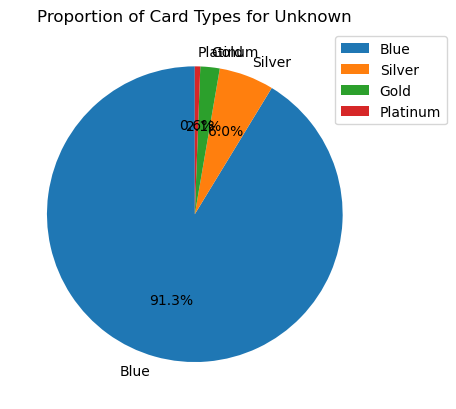


Do you want to try another education level? (Yes/No):  no



=== Main Menu ===
1. Proportion of each card type for a specific education level (Task c1)
2. Monthly trend of average interest earned for each card category (Task c2)
3. Compare average annual fees and acquisition costs across card categories (Task c3)
4. Number of customers per expense type (Stacked by Card Category) (Task c4)
0. Quit


Select an option (0-4):  2


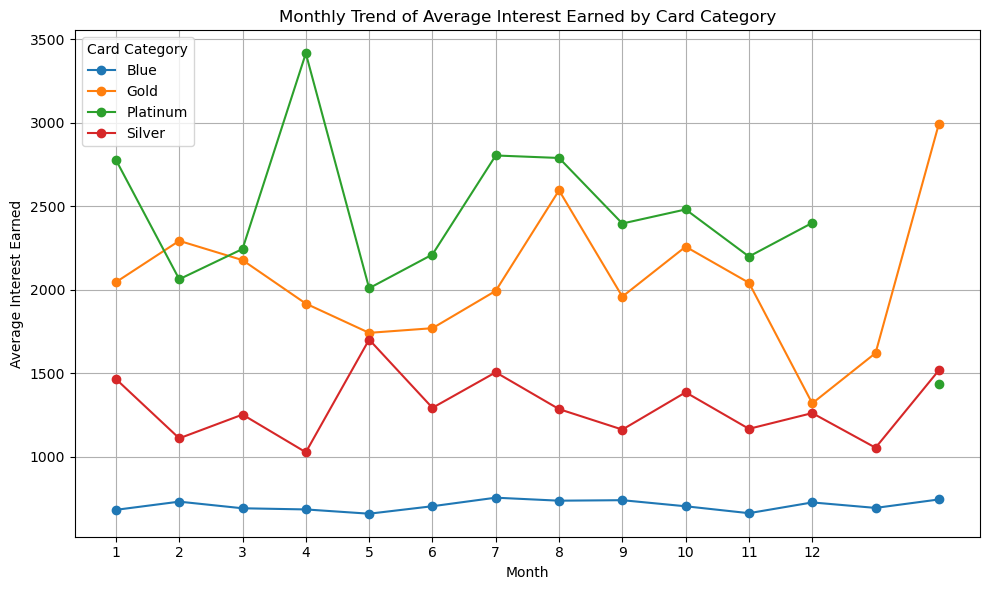


=== Main Menu ===
1. Proportion of each card type for a specific education level (Task c1)
2. Monthly trend of average interest earned for each card category (Task c2)
3. Compare average annual fees and acquisition costs across card categories (Task c3)
4. Number of customers per expense type (Stacked by Card Category) (Task c4)
0. Quit


Select an option (0-4):  3


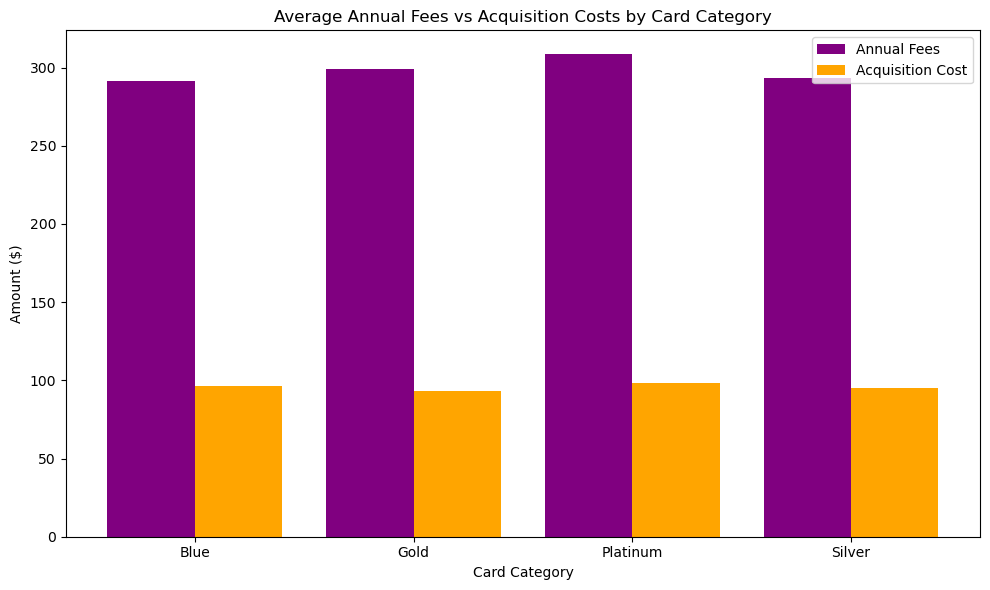


=== Main Menu ===
1. Proportion of each card type for a specific education level (Task c1)
2. Monthly trend of average interest earned for each card category (Task c2)
3. Compare average annual fees and acquisition costs across card categories (Task c3)
4. Number of customers per expense type (Stacked by Card Category) (Task c4)
0. Quit


Select an option (0-4):  4


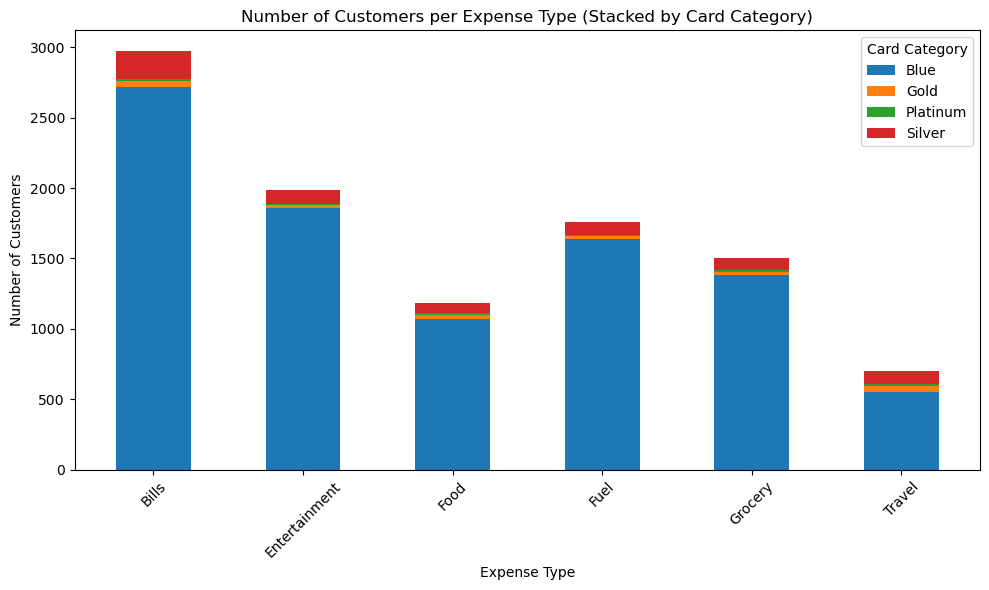


=== Main Menu ===
1. Proportion of each card type for a specific education level (Task c1)
2. Monthly trend of average interest earned for each card category (Task c2)
3. Compare average annual fees and acquisition costs across card categories (Task c3)
4. Number of customers per expense type (Stacked by Card Category) (Task c4)
0. Quit


Select an option (0-4):  0



Thank you for using our customer data explorer. Goodbye!


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
def load_customer_data (file_path):
    df = pd.read_csv(file_path, encoding='utf-8')
    print("Data Frame is loaded")
    return df

# ------------------------------
# Task c1: Proportion of each card type for a specific education level
# ------------------------------

def show_card_type_distribution (df):
    education_levels = df['Education_Level'].dropna().unique()
    while True:
        print("\nSelect an Education Level (or type 0 to return to the main menu):")
        for idx, level in enumerate(education_levels):
            print(f"{idx + 1}. {level}")
        print("0. Return to Main Menu")

        try:
            choice = int(input("Enter the number corresponding to your choice: "))
            if choice == 0:
                break
            elif 1 <= choice <= len(education_levels):
                selected_level = education_levels[choice - 1]
                filtered_df = df[df['Education_Level'] == selected_level]

                if filtered_df.empty:
                    print(f"No data available for {selected_level}.")
                    continue

                card_counts = filtered_df['Card_Category'].value_counts()

                plt.figure()
                plt.pie(card_counts.values, labels=card_counts.index, autopct='%1.1f%%', startangle=90)
                plt.title(f'Proportion of Card Types for {selected_level}')
                plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
                plt.show()

                again = input("\nDo you want to try another education level? (Yes/No): ").strip().lower()
                if again != 'yes':
                    break
            else:
                print("Invalid number. Please select a valid option.")
        except ValueError:
            print("Invalid input. Please enter a number.")

# ------------------------------
# Task c2: Monthly trend of average interest earned for each card category
# ------------------------------

def plot_monthly_interest_trend (df):
    if 'Week_Num' not in df.columns:
        print("Week_Num column is missing!")
        return

    df['Week_Num'] = df['Week_Num'].str.replace('Week-', '').astype(int)
    df['Month'] = df['Week_Num'] // 4 + 1

    monthly_avg_interest = df.groupby(['Month', 'Card_Category'])['Interest_Earned'].mean().unstack()

    plt.figure(figsize=(10, 6))
    for card_cat in monthly_avg_interest.columns:
        plt.plot(monthly_avg_interest.index, monthly_avg_interest[card_cat], marker='o', label=card_cat)

    plt.title('Monthly Trend of Average Interest Earned by Card Category')
    plt.xlabel('Month')
    plt.ylabel('Average Interest Earned')
    plt.legend(title='Card Category')
    plt.grid(True)
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

# ------------------------------
# Task c3: Compare average annual fees and customer acquisition costs
# ------------------------------

def compare_avg_fees_and_acquisition_costs (df):
    avg_fees = df.groupby('Card_Category')['Annual_Fees'].mean()
    avg_acquisition = df.groupby('Card_Category')['Customer_Acq_Cost'].mean()

    card_categories = avg_fees.index
    x_axis = range(len(card_categories))
    bar_width = 0.4

    plt.figure(figsize=(10, 6))
    plt.bar([x - 0.2 for x in x_axis], avg_fees.values, width=bar_width, label='Annual Fees', color='purple')
    plt.bar([x + 0.2 for x in x_axis], avg_acquisition.values, width=bar_width, label='Acquisition Cost', color='orange')

    plt.title('Average Annual Fees vs Acquisition Costs by Card Category')
    plt.xlabel('Card Category')
    plt.ylabel('Amount ($)')
    plt.xticks(x_axis, card_categories)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------
# Task c4: Number of customers per expense type (stacked by card category)
# ------------------------------

def plot_stacked_expense_type_distribution (df):
    grouped = df.groupby(['Exp Type', 'Card_Category']).size().unstack(fill_value=0)

    exp_types = list(grouped.index)
    card_categories = list(grouped.columns)

    x_axis = list(range(len(exp_types)))
    bottom = [0] * len(exp_types)

    plt.figure(figsize=(10, 6))
    for card_cat in card_categories:
        values = grouped[card_cat].tolist()
        plt.bar(x_axis, values, width=0.5, label=card_cat, bottom=bottom)
        bottom = [b + v for b, v in zip(bottom, values)]

    plt.xticks(x_axis, exp_types, rotation=45)
    plt.xlabel("Expense Type")
    plt.ylabel("Number of Customers")
    plt.title("Number of Customers per Expense Type (Stacked by Card Category)")
    plt.legend(title="Card Category")
    plt.tight_layout()
    plt.show()

# ------------------------------
# Main Menu
# ------------------------------

def main_menu(df):
    while True:
        print("\n=== Main Menu ===")
        print("1. Proportion of each card type for a specific education level (Task c1)")
        print("2. Monthly trend of average interest earned for each card category (Task c2)")
        print("3. Compare average annual fees and acquisition costs across card categories (Task c3)")
        print("4. Number of customers per expense type (Stacked by Card Category) (Task c4)")
        print("0. Quit")

        try:
            choice = int(input("Select an option (0-4): "))
            if choice == 0:
                print("\nThank you for using our customer data explorer. Goodbye!")
                break
            elif choice == 1:
                task_c1(df)
            elif choice == 2:
                task_c2(df)
            elif choice == 3:
                task_c3(df)
            elif choice == 4:
                task_c4(df)
            else:
                print("Invalid option. Please select a number between 0 and 4.")
        except ValueError:
            print("Invalid input. Please enter a number.")

# ------------------------------
# Main Function
# ------------------------------

def visualizing_customer_information():
    file_path = "credit_card_customers.csv"
    df_ccard = load_data(file_path)
    main_menu(df_ccard)

if __name__ == "__main__":
    visualizing_customer_information()